# Notebook 01: EDA & Features


## **Intelligent Loan Pricing & Risk Management for Australian Banks**

### **Author: Pranamya Rajbhandari**

### **Goal**
The goal of this project is to develop an end-to-end credit risk management system for Australian banks that:

1. Predicts loan approval and borrower risk using demographic, financial and credit-related information.
2. Optimises loan pricing by converting default risk into risk-based interest rates
3. Develops a borrower risk monitoring framework using financial indicators that can identify customers requiring closer monitoring after loan approval.
4. Segments customers into risk tiers (Prime/Near-Prime/Subprime/High-Risk) with tailored approval strategies
5. Calculates expected loss and portfolio profitability by risk tier

### **Australian Context**
The synthetic dataset incorporates lending characteristics commonly observed in the Australian banking sector, including employment stability, housing ownership, debt servicing capacity, and income-based lending behaviour. The project is designed with consideration for Australian regulatory principles, including guidance from ASIC, APRA, the Reserve Bank of Australia (RBA), and the Privacy Act 1988.

### **Technologies and Tools Used**
* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* SciPy
* Imbalanced-learn (SMOTE)
* Streamlit
* Jupyter Notebook

## **1. Introduction**

Credit risk modeling in banking has two critical purposes:

1. **Approval Decision**: Should we approve this loan?
2. **Pricing Decision**: If approved, what interest rate minimizes expected loss?

This project implements risk-based pricing—converting default probability into optimal interest rates that approve more customers while pricing risk appropriately and maximizing portfolio profitability.

Additionally, an early warning system identifies borrowers showing delinquency signals within 6 months, enabling proactive intervention before defaults occur.

### **Key Components**

**1. Loan Approval & Credit Risk Prediction**
Classification models (Logistic Regression, Random Forest, Gradient Boosting) with SMOTE for imbalanced data handling. Output: Default probability (0-100%).

**2. Risk-Based Pricing Strategy**
Expected Loss = Default Probability × Loss Given Default
Risk Premium = (Expected Loss / Loan Amount) in basis points
Suggested Rate = Base Rate + Risk Premium

**3. Early Warning System**
Time-series features tracking payment degradation and credit utilisation trends. Identifies customers likely to miss payments within 6 months.

**4. Portfolio Analysis**
Profitability by risk tier, expected loss by segment, optimal portfolio composition.

### **Data Overview**

A synthetic Australian consumer lending dataset containing 2,000 loan applications generated using realistic correlations between applicant demographics, financial behaviour, loan characteristics, and repayment risk.

Variables: Annual Income, Employment Status, Credit Score, Interest Rate, Debt-to-Income Ratio, Net Worth, Loan Approved, Risk Score, etc.

### **Methodology**

1. Exploratory Data Analysis - Data quality, missing values, class distribution
2. Feature Engineering - Australian-specific indicators (employment, debt ratios, regional risk)
3. Model Development - Train/test split, SMOTE, cross-validation
4. Risk Score Calculation & Model Evaluation - Probability calibration, ROC-AUC analysis
5. Pricing & Segmentation - Expected loss calculations, risk-based pricing, customer tier assignment
6. Early Warning System - Delinquency prediction and intervention recommendations
7. Deployment - Streamlit interactive dashboard and pricing calculator

### **Expected Outcomes**

A machine learning model capable of accurately predicting loan approval outcomes, generating borrower risk scores, and supporting risk-based pricing decisions through interpretable risk segmentation.

## **2. Import Python Libraries**

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn as sk
import imblearn as imb
import shap
import fairlearn as fl
import os
import create_synthetic_dataset as csd



## **3. Create and Load Dataset**
Display:
* Dataset Shape
* First Five Rows (.head())
* Data Types
* Rename Columns

In [32]:
os.system('python create_synthetic_dataset.py')

df = pd.read_csv(r'dataset\focused_synthetic_loan_data.csv')
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,DebtToIncomeRatio,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-03,45,68809,546,Employed,Associate,24,22777,48,Married,...,0.962392,4,125361,0.200508,0.207511,702.259886,0.069223,0.191673,1,1.271706
1,2018-01-04,38,15000,575,Employed,High School,16,10155,12,Married,...,0.759374,8,28784,0.173806,0.163413,923.012748,0.123102,0.860921,1,3.977991
2,2018-01-05,47,137921,522,Employed,Doctorate,26,263359,360,Divorced,...,0.866965,7,5836,0.317120,0.250000,5489.925450,0.044195,0.521812,0,2.110470
3,2018-01-06,58,39656,553,Employed,Bachelor,36,41676,24,Single,...,0.833397,6,43212,0.189159,0.200235,2121.612296,0.075930,0.717741,0,3.065980
4,2018-01-09,37,82748,416,Employed,Bachelor,18,15629,24,Single,...,0.783230,8,381200,0.257414,0.250000,834.143491,0.072499,0.193448,1,2.082586


In [33]:
df.shape

(2000, 36)

In [34]:
import re

# Convert camelCase headers to readable names with spaces
# Example: ApplicationDate -> Application Date
#          RiskScore -> Risk Score

df.columns = [
    re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower()
    for col in df.columns
]
df.head()

,application_date,age,annual_income,credit_score,employment_status,education_level,experience,loan_amount,loan_duration,marital_status,...,utility_bills_payment_history,job_tenure,net_worth,base_interest_rate,interest_rate,monthly_loan_payment,debt_to_income_ratio,total_debt_to_income_ratio,loan_approved,risk_score
0,2018-01-03,45,68809,546,Employed,Associate,24,22777,48,Married,...,0.962392,4,125361,0.200508,0.207511,702.259886,0.069223,0.191673,1,1.271706
1,2018-01-04,38,15000,575,Employed,High School,16,10155,12,Married,...,0.759374,8,28784,0.173806,0.163413,923.012748,0.123102,0.860921,1,3.977991
2,2018-01-05,47,137921,522,Employed,Doctorate,26,263359,360,Divorced,...,0.866965,7,5836,0.317120,0.250000,5489.925450,0.044195,0.521812,0,2.110470
3,2018-01-06,58,39656,553,Employed,Bachelor,36,41676,24,Single,...,0.833397,6,43212,0.189159,0.200235,2121.612296,0.075930,0.717741,0,3.065980
4,2018-01-09,37,82748,416,Employed,Bachelor,18,15629,24,Single,...,0.783230,8,381200,0.257414,0.250000,834.143491,0.072499,0.193448,1,2.082586


In [35]:
df.dtypes

application_date                     str
age                                int64
annual_income                      int64
credit_score                       int64
employment_status                    str
education_level                      str
experience                         int64
loan_amount                        int64
loan_duration                      int64
marital_status                       str
number_of_dependents               int64
home_ownership_status                str
monthly_debt_payments              int64
credit_card_utilisation_rate     float64
number_of_open_credit_lines        int64
number_of_credit_inquiries         int64
bankruptcy_history                 int64
loan_purpose                         str
previous_loan_defaults             int64
payment_history                    int64
length_of_credit_history           int64
savings_account_balance            int64
checking_account_balance           int64
total_assets                       int64
total_liabilitie

## **4. Data Observation and Data Cleaning**
**Overview**

The dataset was examined to understand its structure, data types, summary statistics, and any missing values. Numerical and categorical features were identified for furthering preprocessing.

**Data Cleaning**
Preprocessing: 
* Checked dataset shape and feature information
* Analysed summary statistics and missing values
* Imputed missing value (none found in dataset: checked with .isna() and .isnull())
* Checked and removed duplicate records if found
* Verified data quality before model training

**Observation**
* The dataset contained both numerical and categorical features
* Missing values were successfully handled using median and mode imputation
* No significant data quality issues remained after preprocessing
* The cleaned dataset was ready for exploratory analysis and model development

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   application_date               2000 non-null   str    
 1   age                            2000 non-null   int64  
 2   annual_income                  2000 non-null   int64  
 3   credit_score                   2000 non-null   int64  
 4   employment_status              2000 non-null   str    
 5   education_level                2000 non-null   str    
 6   experience                     2000 non-null   int64  
 7   loan_amount                    2000 non-null   int64  
 8   loan_duration                  2000 non-null   int64  
 9   marital_status                 2000 non-null   str    
 10  number_of_dependents           2000 non-null   int64  
 11  home_ownership_status          2000 non-null   str    
 12  monthly_debt_payments          2000 non-null   int64  
 13 

**Observations on Key Attributes: Age, Annual Income, Credit Score, Employment Status, Loan Amount**

In [37]:
df["age"].unique()

array([45, 38, 47, 58, 37, 49, 34, 46, 42, 18, 19, 33, 27, 43, 29, 23, 57,
       40, 22, 41, 26, 44, 32, 36, 62, 39, 25, 24, 48, 31, 52, 35, 51, 56,
       30, 50, 69, 53, 66, 28, 21, 55, 20, 72, 80, 67, 65, 61, 59, 54, 64,
       63, 76, 60, 70, 71, 68, 78, 77])

In [38]:
df["annual_income"].describe()

count      2000.000000
mean      57562.950000
std       42750.529709
min        1034.000000
25%       29413.750000
50%       46681.500000
75%       72534.500000
max      300000.000000
Name: annual_income, dtype: float64

In [39]:
df["credit_score"].describe()

count    2000.000000
mean      572.026000
std        49.669577
min       396.000000
25%       541.000000
50%       579.000000
75%       607.000000
max       696.000000
Name: credit_score, dtype: float64

In [40]:
df["employment_status"].unique()

<ArrowStringArray>
['Employed', 'Self-Employed', 'Unemployed']
Length: 3, dtype: str

In [41]:
df["loan_amount"].describe()

count      2000.000000
mean      65454.100500
std       79602.420402
min        1423.000000
25%       14582.500000
50%       23553.000000
75%      112755.000000
max      545047.000000
Name: loan_amount, dtype: float64

In [42]:
df.describe()

,age,annual_income,credit_score,experience,loan_amount,loan_duration,number_of_dependents,monthly_debt_payments,credit_card_utilisation_rate,number_of_open_credit_lines,...,utility_bills_payment_history,job_tenure,net_worth,base_interest_rate,interest_rate,monthly_loan_payment,debt_to_income_ratio,total_debt_to_income_ratio,loan_approved,risk_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,40.183000,57562.950000,572.026000,17.931000,65454.100500,117.612000,1.540500,453.860500,0.277492,3.017500,...,0.801434,4.985000,6.980980e+04,0.210794,0.203168,1537.132560,0.111407,0.560867,0.627000,2.637379
std,11.526532,42750.529709,49.669577,11.316062,79602.420402,115.127115,1.378154,397.444479,0.157381,1.700482,...,0.119641,2.210479,1.066020e+05,0.045610,0.037418,1521.355502,0.104034,0.546464,0.483723,1.526969
min,18.000000,1034.000000,396.000000,0.000000,1423.000000,12.000000,0.000000,35.000000,0.001224,0.000000,...,0.318713,0.000000,1.017000e+03,0.118272,0.101089,71.510819,0.017337,0.052987,0.000000,0.000000
25%,32.000000,29413.750000,541.000000,9.750000,14582.500000,36.000000,0.000000,200.000000,0.156996,2.000000,...,0.726545,3.000000,8.554750e+03,0.175421,0.172318,505.040496,0.062006,0.215073,0.000000,1.602184
50%,40.000000,46681.500000,579.000000,17.000000,23553.000000,60.000000,1.000000,332.000000,0.252188,3.000000,...,0.822004,5.000000,3.152450e+04,0.200732,0.202769,805.730826,0.088683,0.348079,1.000000,2.333585
75%,48.000000,72534.500000,607.000000,26.000000,112755.000000,240.000000,3.000000,564.250000,0.375493,4.000000,...,0.895617,6.000000,8.828550e+04,0.241623,0.245705,2340.394596,0.129528,0.707932,1.000000,3.307678
max,80.000000,300000.000000,696.000000,58.000000,545047.000000,360.000000,5.000000,4105.000000,0.802016,11.000000,...,0.994403,12.000000,1.102901e+06,0.355273,0.250000,11361.933318,2.000000,3.000000,1.000000,9.974034


**Check Duplicates**

In [43]:
df.duplicated().sum()

np.int64(0)

**Check for missing values & NULL in the dataset**

In [44]:
df.isnull().sum()

application_date                 0
age                              0
annual_income                    0
credit_score                     0
employment_status                0
education_level                  0
experience                       0
loan_amount                      0
loan_duration                    0
marital_status                   0
number_of_dependents             0
home_ownership_status            0
monthly_debt_payments            0
credit_card_utilisation_rate     0
number_of_open_credit_lines      0
number_of_credit_inquiries       0
bankruptcy_history               0
loan_purpose                     0
previous_loan_defaults           0
payment_history                  0
length_of_credit_history         0
savings_account_balance          0
checking_account_balance         0
total_assets                     0
total_liabilities                0
monthly_income                   0
utility_bills_payment_history    0
job_tenure                       0
net_worth           

In [45]:
df.isna().sum()

application_date                 0
age                              0
annual_income                    0
credit_score                     0
employment_status                0
education_level                  0
experience                       0
loan_amount                      0
loan_duration                    0
marital_status                   0
number_of_dependents             0
home_ownership_status            0
monthly_debt_payments            0
credit_card_utilisation_rate     0
number_of_open_credit_lines      0
number_of_credit_inquiries       0
bankruptcy_history               0
loan_purpose                     0
previous_loan_defaults           0
payment_history                  0
length_of_credit_history         0
savings_account_balance          0
checking_account_balance         0
total_assets                     0
total_liabilities                0
monthly_income                   0
utility_bills_payment_history    0
job_tenure                       0
net_worth           

**Further Observation**

In [46]:
df["loan_purpose"].value_counts()

loan_purpose
Home                  607
Debt Consolidation    503
Auto                  404
Education             296
Other                 190
Name: count, dtype: int64

In [47]:
df["loan_approved"].value_counts()

loan_approved
1    1254
0     746
Name: count, dtype: int64

In [48]:
df["interest_rate"].unique()

array([0.20751095, 0.1634129 , 0.25      , ..., 0.18431474, 0.15780531,
       0.22689482], shape=(1540,))

In [49]:
df["education_level"].value_counts()    

education_level
High School    611
Bachelor       563
Associate      417
Master         305
Doctorate      104
Name: count, dtype: int64

## **5. Exploratory Data Analysis (EDA)**




Exploratory data analysis involves exploring underlying structures, patterns, relationships, and outliers within the data before formal modeling can commence.

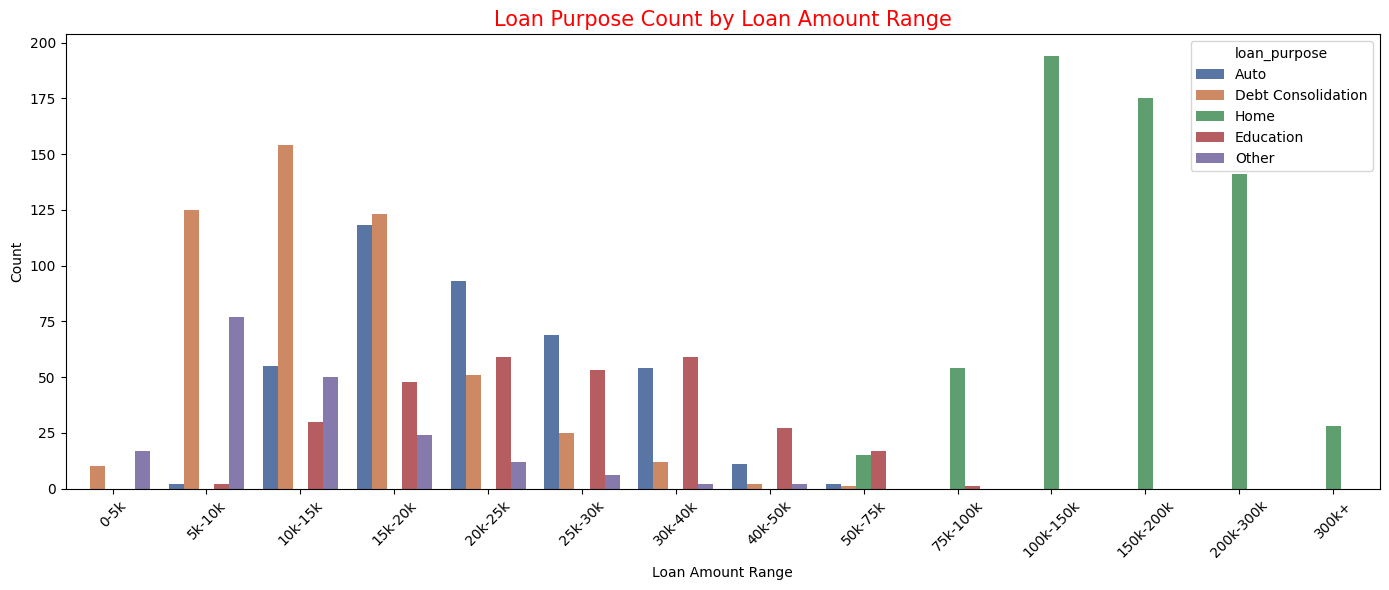

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Create a copy for visualization only
df_plot = df.copy()

# Create loan amount ranges (bins)
bins = [
    0, 5000, 10000, 15000, 20000, 25000, 30000, 40000,
    50000, 75000, 100000, 150000, 200000, 300000,
    df_plot['loan_amount'].max()
]

labels = [
    '0-5k', '5k-10k', '10k-15k', '15k-20k', '20k-25k',
    '25k-30k', '30k-40k', '40k-50k', '50k-75k',
    '75k-100k', '100k-150k', '150k-200k', '200k-300k', '300k+'
]

# Add the binned column ONLY to the copy
df_plot['loan_amount_range'] = pd.cut(
    df_plot['loan_amount'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Plot
plt.figure(figsize=(14, 6))
ax = sns.countplot(
    data=df_plot,
    x='loan_amount_range',
    hue='loan_purpose',
    palette='deep'
)

plt.title("Loan Purpose Count by Loan Amount Range", color='red', fontsize=15)
plt.xlabel("Loan Amount Range")
plt.ylabel("Count")
plt.xticks(rotation=45)

ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

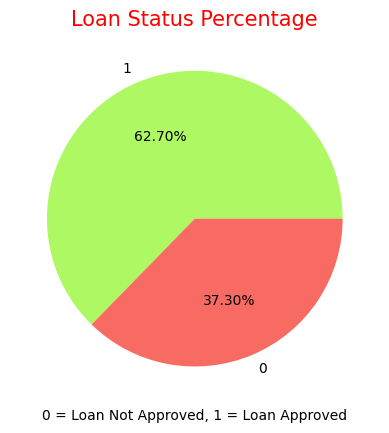

In [51]:
plt.pie(df['loan_approved'].value_counts(),labels=df['loan_approved'].value_counts().index,autopct='%1.2f%%',colors=["#ADF863","#F86B63",])
plt.title("Loan Status Percentage",color='red',fontsize=15)
plt.xlabel("0 = Loan Not Approved, 1 = Loan Approved")
plt.show()

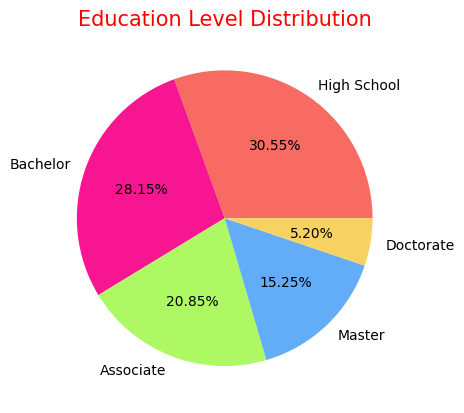

In [52]:
plt.pie(df['education_level'].value_counts(),labels=df['education_level'].value_counts().index,autopct='%1.2f%%',colors=["#F86B63","#F81592","#ADF863","#63ADF8","#F8D163"])
plt.title("Education Level Distribution", color='red', fontsize=15)
plt.show()

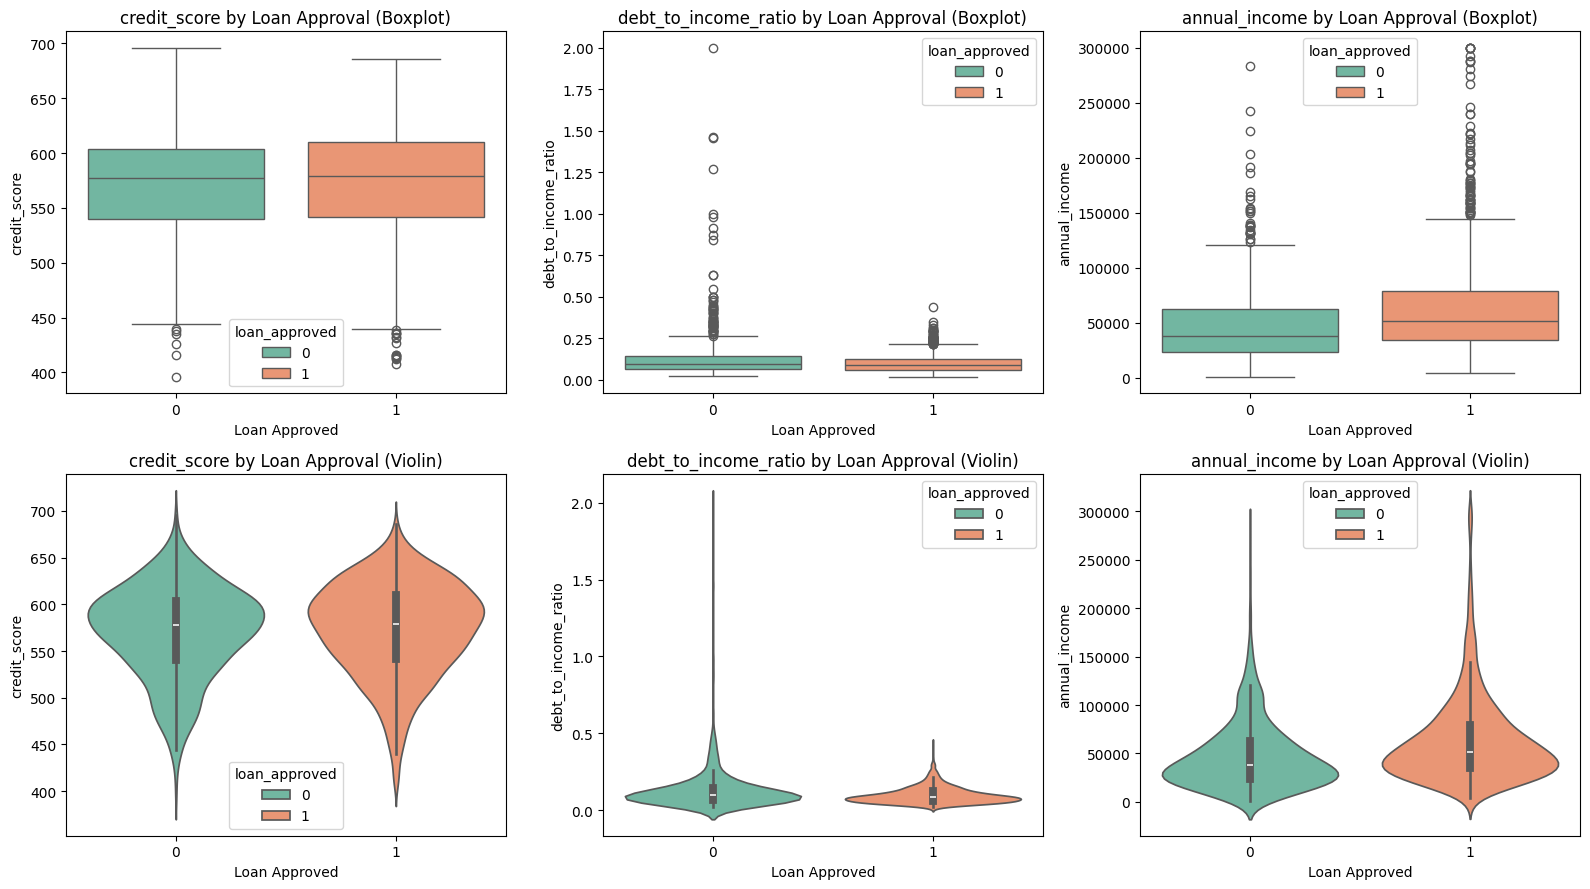

In [53]:
# Set up figure with 3 columns (one per variable)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

variables = ['credit_score', 'debt_to_income_ratio', 'annual_income']

# Row 1: Boxplots
for i, var in enumerate(variables):
    sns.boxplot(data=df, x='loan_approved', y=var, ax=axes[0, i], hue = 'loan_approved', palette='Set2')
    axes[0, i].set_title(f'{var} by Loan Approval (Boxplot)')
    axes[0, i].set_xlabel('Loan Approved')

# Row 2: Violin plots
for i, var in enumerate(variables):
    sns.violinplot(data=df, x='loan_approved', y=var, ax=axes[1, i], hue = 'loan_approved', palette='Set2')
    axes[1, i].set_title(f'{var} by Loan Approval (Violin)')
    axes[1, i].set_xlabel('Loan Approved')

plt.tight_layout()
plt.show()

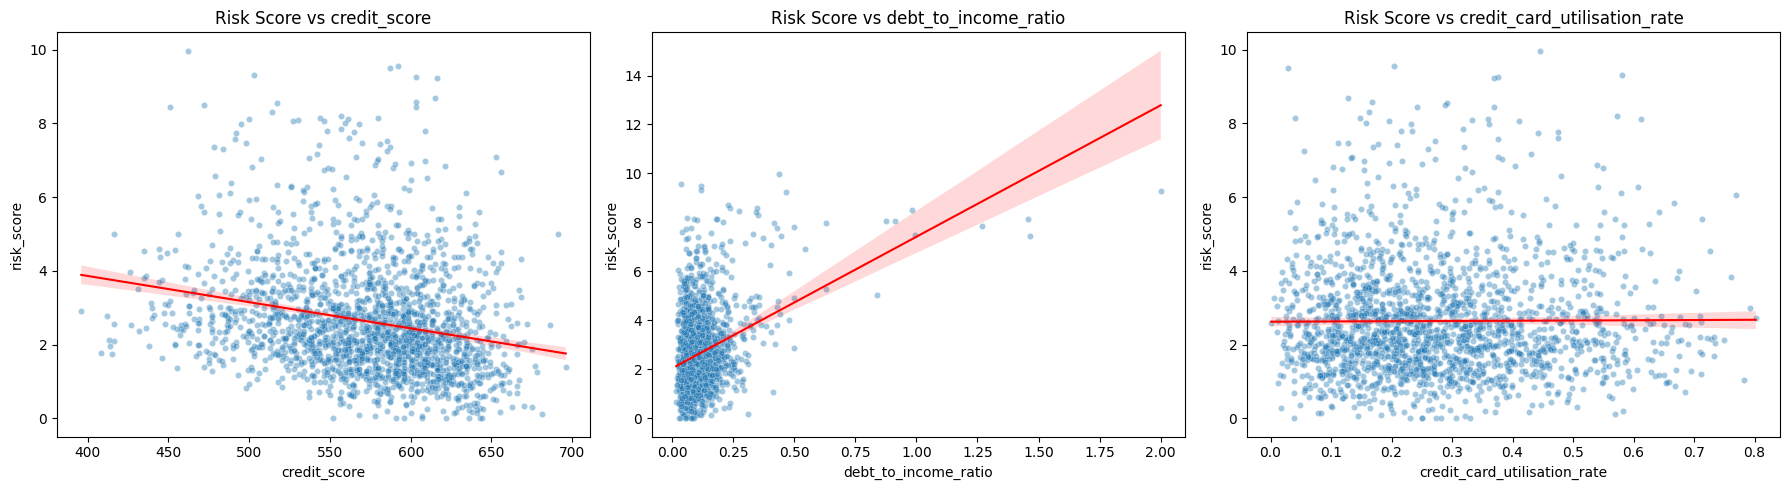

In [54]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables = ['credit_score', 'debt_to_income_ratio', 'credit_card_utilisation_rate']

for i, var in enumerate(variables):
    sns.scatterplot(
        data=df, x=var, y='risk_score',
        alpha=0.4, s=20, ax=axes[i]
    )
    # add a regression trendline to make the relationship easier to read
    sns.regplot(
        data=df, x=var, y='risk_score',
        scatter=False, ax=axes[i], color='red', line_kws={'linewidth': 1.5}
    )
    axes[i].set_title(f'Risk Score vs {var}')

plt.tight_layout()
plt.show()

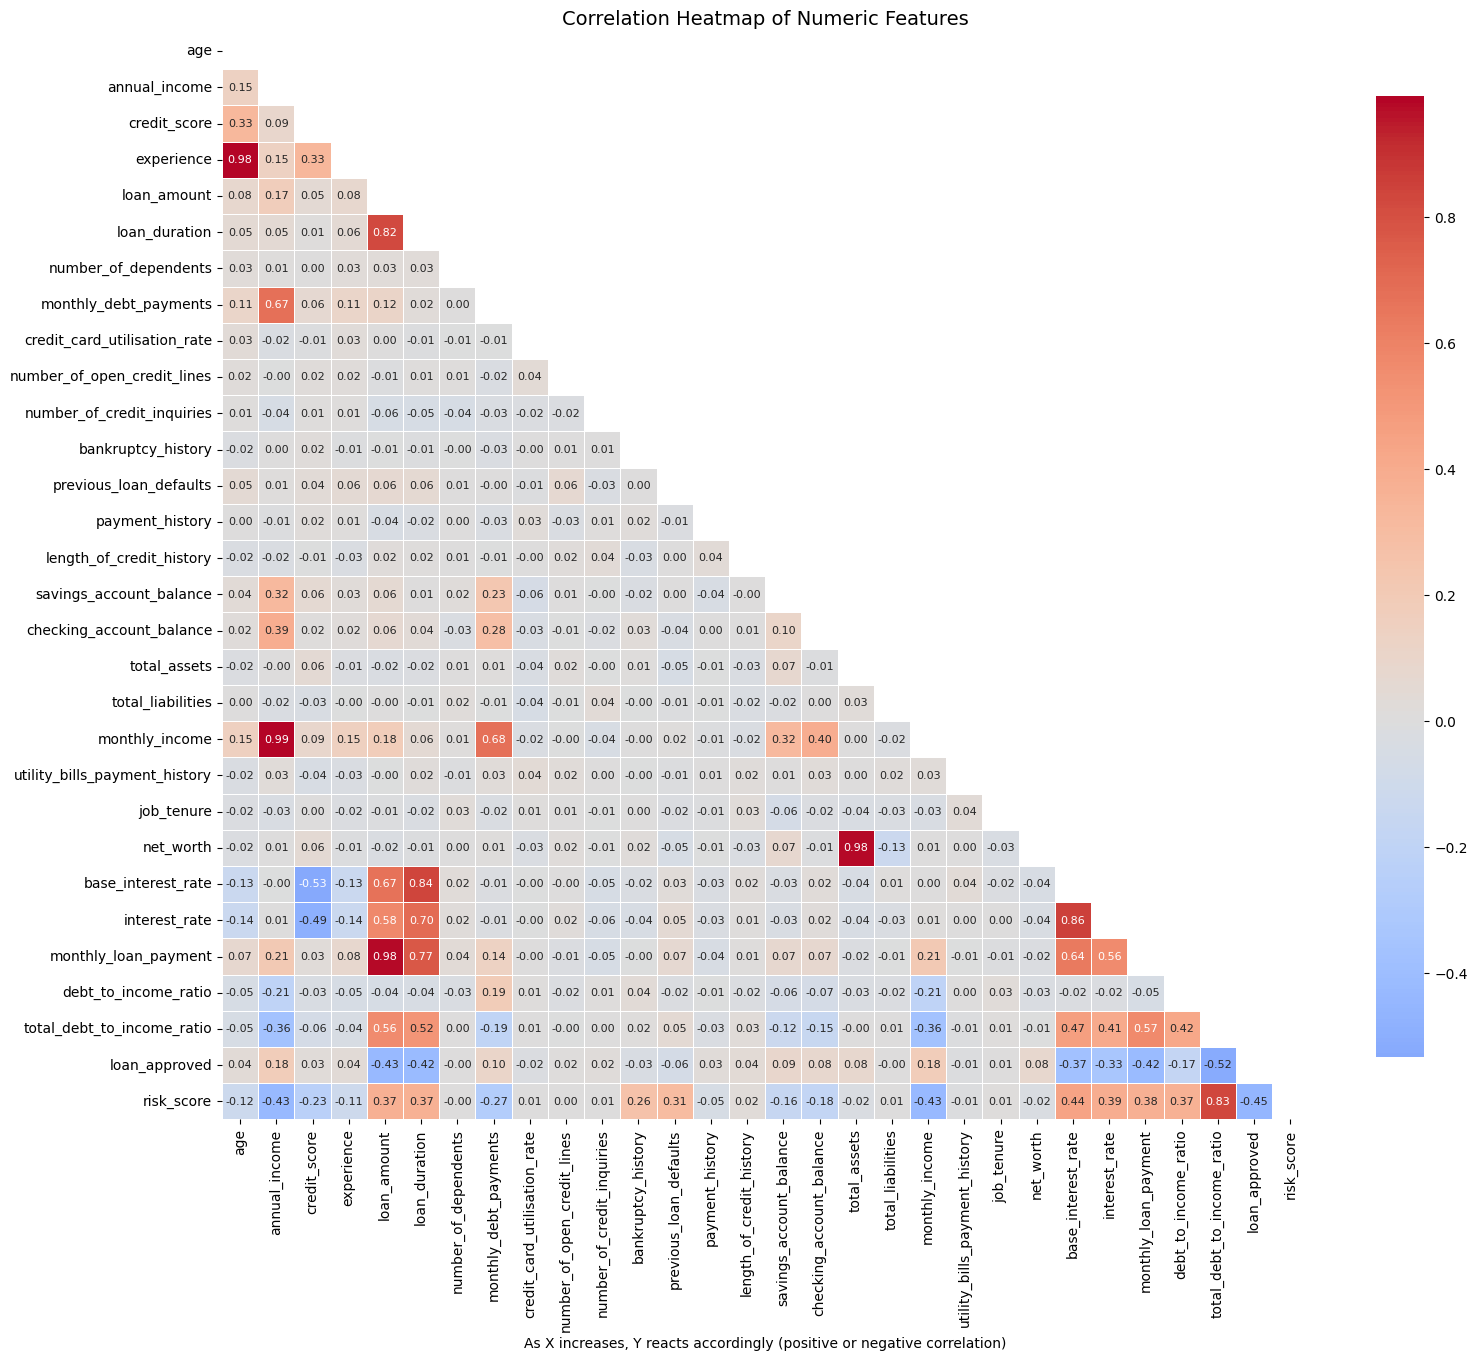

In [55]:
# Select only numeric columns (drops ApplicationDate, EmploymentStatus, etc.)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Mask the upper triangle so you're not reading duplicate info
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.tight_layout()
plt.xlabel("As X increases, Y reacts accordingly (positive or negative correlation)")
plt.show()

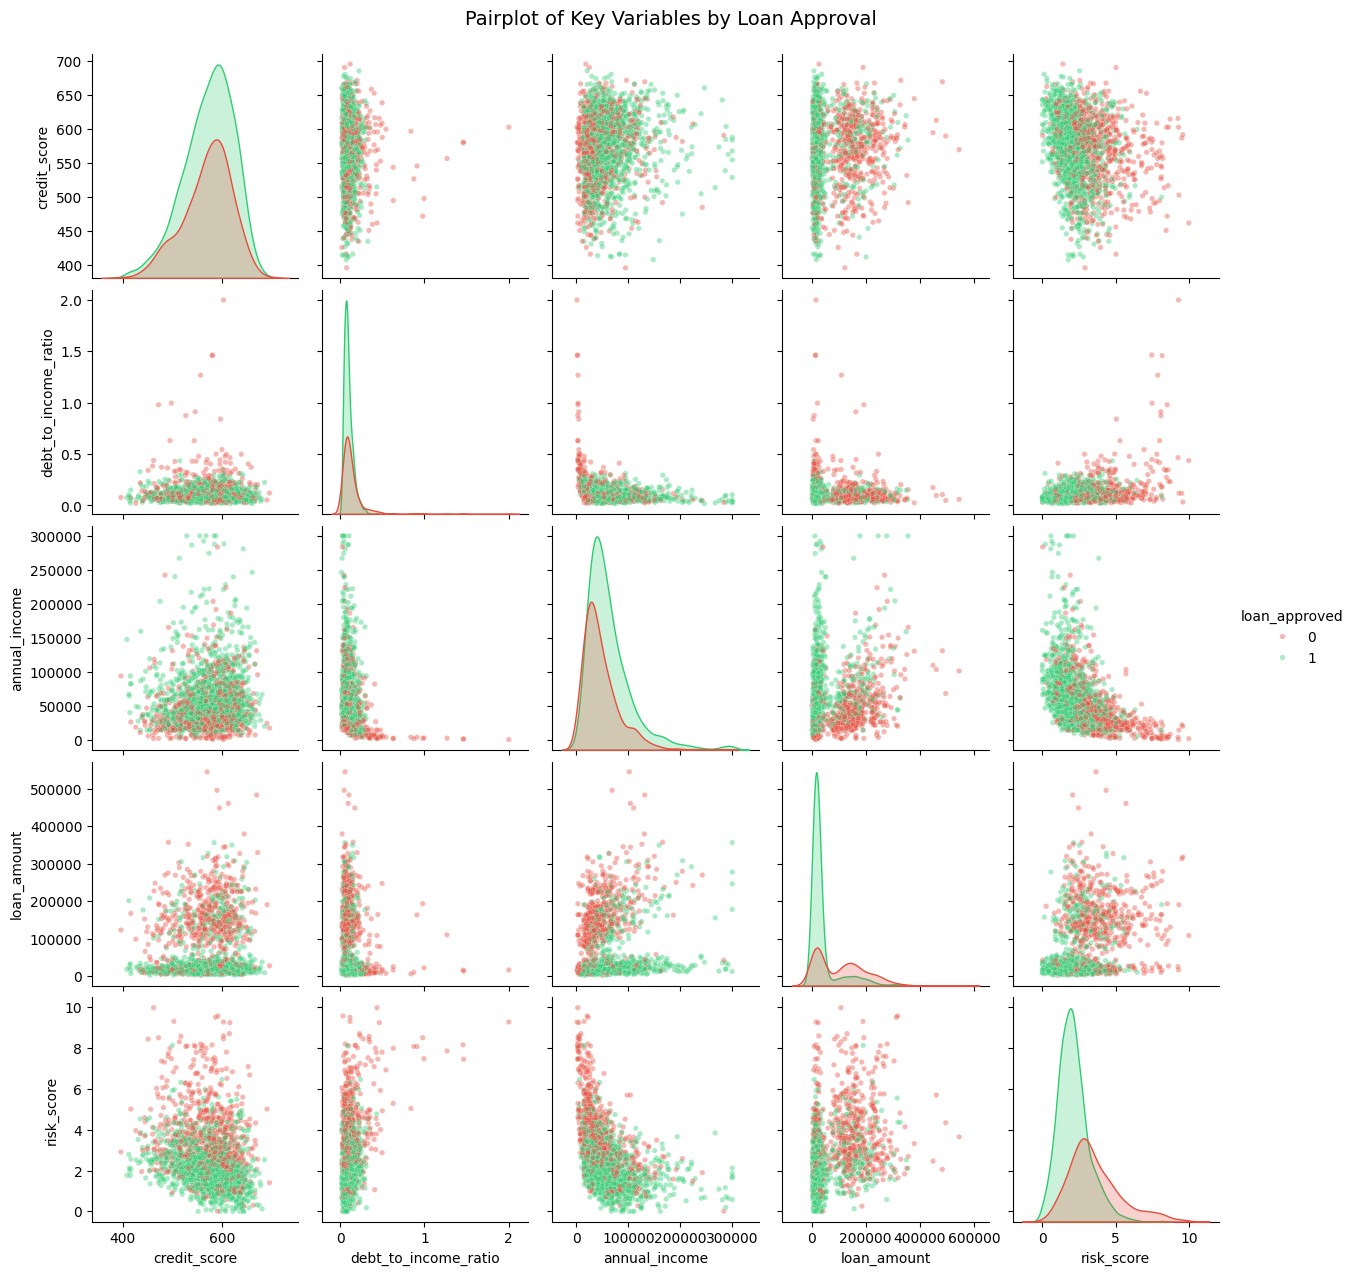

In [56]:
# Map LoanApproved to readable labels for the legend

variables = ['credit_score', 'debt_to_income_ratio', 'annual_income', 'loan_amount', 'risk_score']

g = sns.pairplot(
    df,
    vars=variables,
    hue='loan_approved',
    #1 = Approved, 0 = Denied
    palette={1: '#2ecc71', 0: '#e74c3c'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    height=2.5
)

g.fig.suptitle('Pairplot of Key Variables by Loan Approval', y=1.02, fontsize=14)
plt.show()

## **6. Feature Engineering**

Selecting, Manipulating, and tranforming the raw data into features (inputs) to improve performance and accuracy for machine learning models.

In [57]:
df_features = df.copy()
df_features.columns = df_features.columns.str.replace('([A-Z])', r'_\1', regex=True).str.lower().str.lstrip('_')


# Emplyoment stability features
df_features['employment_stability'] = (df_features['job_tenure'] >= 3).astype(int)
df_features['low_employment_risk'] = (df_features['job_tenure'] >= 5).astype(int)
df_features['employment_tenure_squared'] = df_features['job_tenure'] ** 2
df_features['recent_job_change'] = (df_features['job_tenure'] < 1).astype(int)

# Debt burden and financial health features
df_features['high_debt_burden'] = (df_features['debt_to_income_ratio'] > 0.43).astype(int)
df_features['debt_to_assets_ratio'] = df_features['total_liabilities'] / (df_features['total_assets'] + 1)
df_features['net_worth_risk'] = (df_features['net_worth'] < 0).astype(int)
df_features['financial_cushion'] = df_features['savings_account_balance'] + df_features['checking_account_balance']
df_features['savings_to_loan_ratio'] = df_features['financial_cushion'] / (df_features['loan_amount'] + 1)

# Credit behavior & history features
df_features['good_payment_history'] = (df_features['payment_history'] >= 22).astype(int)
df_features['new_credit_user'] = (df_features['length_of_credit_history'] < 24).astype(int)
df_features['credit_seeking_behavior'] = (df_features['number_of_credit_inquiries'] > 2).astype(int)
df_features['high_card_utilisation'] = (df_features['credit_card_utilisation_rate'] > 0.7).astype(int)
df_features['number_open_accounts_risk'] = (df_features['number_of_open_credit_lines'] > 5).astype(int)

# Credit score bands 
df_features['excellent_credit'] = (df_features['credit_score'] >= 800).astype(int)
df_features['very_good_credit'] = ((df_features['credit_score'] >= 750) & (df_features['credit_score'] < 800)).astype(int)
df_features['good_credit'] = ((df_features['credit_score'] >= 700) & (df_features['credit_score'] < 750)).astype(int)
df_features['fair_credit'] = ((df_features['credit_score'] >= 650) & (df_features['credit_score'] < 700)).astype(int)
df_features['poor_credit'] = (df_features['credit_score'] < 650).astype(int)

# Housing stability & ownership features
df_features['home_owner'] = (df_features['home_ownership_status'] == 'Own').astype(int)
df_features['mortgaged_home'] = (df_features['home_ownership_status'] == 'Mortgage').astype(int)
df_features['renting'] = (df_features['home_ownership_status'] == 'Rent').astype(int)

# Income stability & financial buffer features
df_features['above_median_income'] = (df_features['annual_income'] > 65000).astype(int)
df_features['monthly_surplus'] = df_features['monthly_income'] - df_features['monthly_debt_payments']
df_features['insufficient_income_buffer'] = (df_features['monthly_surplus'] < 1000).astype(int)

# Dependents & family responsibilities features
df_features['has_dependents'] = (df_features['number_of_dependents'] > 0).astype(int)
df_features['high_dependent_burden'] = (df_features['number_of_dependents'] >= 3).astype(int)
df_features['single_with_dependents'] = (
    (df_features['marital_status'] == 'Single') & 
    (df_features['number_of_dependents'] > 0)
).astype(int)

# Education level Features
education_map = {'High School': 1, 'Associate': 2, 'Bachelor': 3, 'Master': 4, 'Doctorate': 5}
df_features['education_score'] = df_features['education_level'].map(education_map)
df_features['advanced_degree'] = df_features['education_level'].isin(['Master', 'Doctorate']).astype(int)

# Loan characteristics & purpose features
df_features['long_term_loan'] = (df_features['loan_duration'] > 36).astype(int)
df_features['large_loan_amount'] = (df_features['loan_amount'] > 100000).astype(int)
df_features['loan_to_income_ratio'] = df_features['loan_amount'] / (df_features['annual_income'] + 1)
df_features['risky_loan_purpose'] = df_features['loan_purpose'].isin(['Debt Consolidation', 'Other']).astype(int)

# Composite financial stress score and risk factor count
df_features['financial_stress_score'] = (
    df_features['high_debt_burden'] +
    df_features['new_credit_user'] +
    df_features['credit_seeking_behavior'] +
    df_features['high_card_utilisation'] +
    df_features['recent_job_change'] +
    df_features['insufficient_income_buffer'] +
    df_features['net_worth_risk']
)
df_features['multiple_risk_factors'] = (df_features['financial_stress_score'] >= 3).astype(int)

# Bankruptcy and default history features
df_features['bankruptcy_flag'] = df_features['bankruptcy_history'].astype(int)
df_features['previous_defaults'] = df_features['previous_loan_defaults'].astype(int)
df_features['default_history'] = (df_features['bankruptcy_flag'] | df_features['previous_defaults']).astype(int)

# Early warning indicators for potential financial distress
df_features['utility_payment_risk'] = (df_features['utility_bills_payment_history'] < 0.7).astype(int)
df_features['risky_behavior_cluster'] = (
    (df_features['high_card_utilisation'] == 1) &
    (df_features['credit_seeking_behavior'] == 1) &
    (df_features['monthly_surplus'] < 1000)
).astype(int)

# Age-related risk features
df_features['young_borrower'] = (df_features['age'] < 30).astype(int)
df_features['retirement_age'] = (df_features['age'] > 65).astype(int)

# Marital status features
df_features['married'] = (df_features['marital_status'] == 'Married').astype(int)

print(f"\nOriginal features: {len(df.columns)}")
print(f"Engineered features added: {len(df_features.columns) - len(df.columns)}")
print(f"Total features: {len(df_features.columns)}")
print("\nNew features created:")
new_features = set(df_features.columns) - set(df.columns)
for feat in sorted(new_features):
    print(f"  - {feat}")



Original features: 36
Engineered features added: 44
Total features: 80

New features created:
  - above_median_income
  - advanced_degree
  - bankruptcy_flag
  - credit_seeking_behavior
  - debt_to_assets_ratio
  - default_history
  - education_score
  - employment_stability
  - employment_tenure_squared
  - excellent_credit
  - fair_credit
  - financial_cushion
  - financial_stress_score
  - good_credit
  - good_payment_history
  - has_dependents
  - high_card_utilisation
  - high_debt_burden
  - high_dependent_burden
  - home_owner
  - insufficient_income_buffer
  - large_loan_amount
  - loan_to_income_ratio
  - long_term_loan
  - low_employment_risk
  - married
  - monthly_surplus
  - mortgaged_home
  - multiple_risk_factors
  - net_worth_risk
  - new_credit_user
  - number_open_accounts_risk
  - poor_credit
  - previous_defaults
  - recent_job_change
  - renting
  - retirement_age
  - risky_behavior_cluster
  - risky_loan_purpose
  - savings_to_loan_ratio
  - single_with_dependent

TOP 20 FEATURES BY CORRELATION WITH LOAN APPROVAL

total_debt_to_income_ratio    0.517755
risk_score                    0.453248
large_loan_amount             0.436762
loan_amount                   0.426240
monthly_loan_payment          0.423444
loan_duration                 0.422709
base_interest_rate            0.372562
loan_to_income_ratio          0.351852
interest_rate                 0.330773
risky_loan_purpose            0.248755
long_term_loan                0.222559
savings_to_loan_ratio         0.210000
insufficient_income_buffer    0.193718
monthly_surplus               0.186079
monthly_income                0.184286
annual_income                 0.183263
debt_to_income_ratio          0.172103
above_median_income           0.134626
high_debt_burden              0.133391
multiple_risk_factors         0.128092
Name: loan_approved, dtype: float64


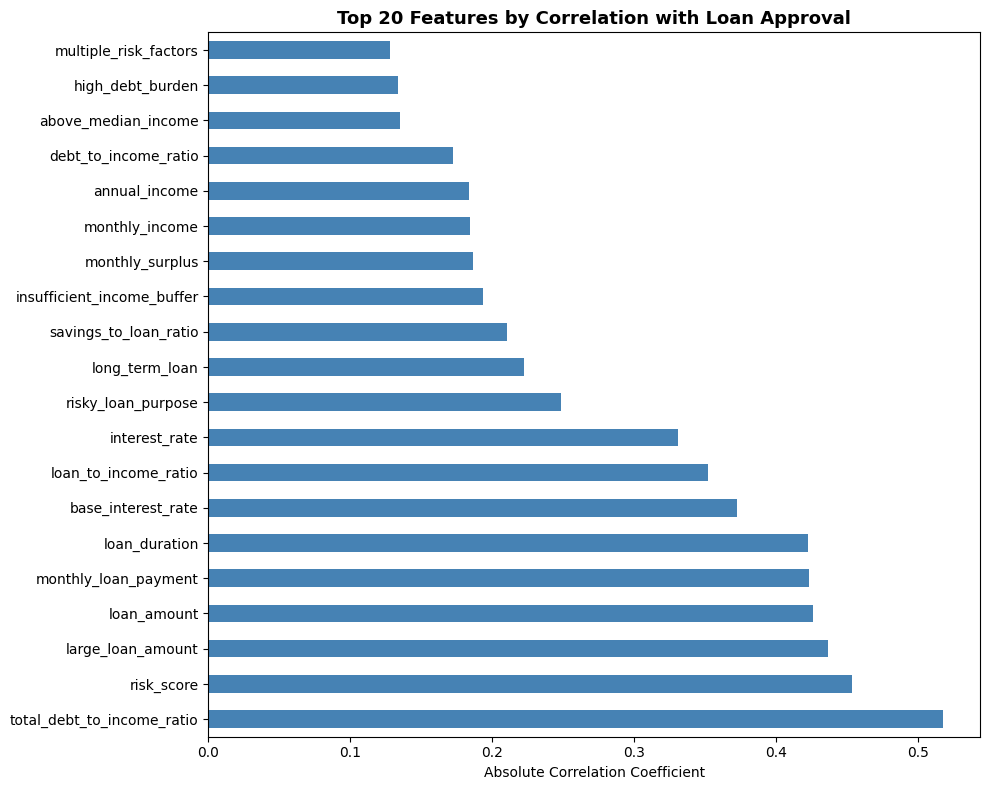

DATA QUALITY CHECKS

Missing values: 0
Infinite values: 0
Total rows: 2000
Total columns: 80

Target Variable Distribution (loan_approved):
loan_approved
1    1254
0     746
Name: count, dtype: int64
Approval rate: 62.7%


In [58]:
# Feature correlation with target variable (loan_approved)
numeric_cols = df_features.select_dtypes(include=[np.number]).columns
feature_corr = df_features[numeric_cols].corr()['loan_approved'].drop('loan_approved').abs().sort_values(ascending=False)

print("TOP 20 FEATURES BY CORRELATION WITH LOAN APPROVAL\n")
print(feature_corr.head(20))

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 8))
feature_corr.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features by Correlation with Loan Approval', fontsize=13, fontweight='bold')
ax.set_xlabel('Absolute Correlation Coefficient')
plt.tight_layout()
plt.show()

# Data Quality Checks
print("DATA QUALITY CHECKS")
print(f"\nMissing values: {df_features.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(df_features.select_dtypes(include=[np.number])).sum().sum()}")
print(f"Total rows: {len(df_features)}")
print(f"Total columns: {len(df_features.columns)}")

print("\nTarget Variable Distribution (loan_approved):")
print(df_features['loan_approved'].value_counts())
print(f"Approval rate: {(df_features['loan_approved'] == 1).sum() / len(df_features) * 100:.1f}%")

Applied encoding to categorical variables for machine learning models and feature scaling to improve Logistic Regression performance and model interpretability.

In [59]:
# Categorical Encoding

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Identify categorical columns still in the data
categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# Create a copy for modeling
df_model = df_features.copy()

# Label encode categorical variables
label_encoders = {}
for col in categorical_cols:
    if col != 'application_date':  # Skip date column
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col])
        label_encoders[col] = le
        print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nAll columns now numeric: {df_model.select_dtypes(include=[np.number]).shape[1]} features")

# # Scaling

# # Scale only the feature columns (NOT the target)
# scaler = StandardScaler()
# numeric_cols = df_model.select_dtypes(include=[np.number]).columns.drop('loan_approved')
# df_model[numeric_cols] = scaler.fit_transform(df_model[numeric_cols])

print(f"\nFeatures scaled using StandardScaler")
print(f"Mean of scaled features (should be ~0): {df_model[numeric_cols].mean().mean():.6f}")
print(f"Std of scaled features (should be ~1): {df_model[numeric_cols].std().mean():.6f}")

# Prepare final dataset for modeling

print(f"\nData prepared for modeling: {df_model.shape}")
print(f"Total features: {len(df_model.columns)}")

# Save for next notebook
folder_path = r"Dataset"
df_model.to_csv(os.path.join(folder_path, 'data_engineered_for_modeling.csv'), index=False)
print("\nFocused synthetic data saved to 'data_engineered_for_modeling.csv'")

Categorical columns to encode: ['application_date', 'employment_status', 'education_level', 'marital_status', 'home_ownership_status', 'loan_purpose']
Encoded employment_status: {'Employed': np.int64(0), 'Self-Employed': np.int64(1), 'Unemployed': np.int64(2)}
Encoded education_level: {'Associate': np.int64(0), 'Bachelor': np.int64(1), 'Doctorate': np.int64(2), 'High School': np.int64(3), 'Master': np.int64(4)}
Encoded marital_status: {'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2), 'Widowed': np.int64(3)}
Encoded home_ownership_status: {'Mortgage': np.int64(0), 'Other': np.int64(1), 'Own': np.int64(2), 'Rent': np.int64(3)}
Encoded loan_purpose: {'Auto': np.int64(0), 'Debt Consolidation': np.int64(1), 'Education': np.int64(2), 'Home': np.int64(3), 'Other': np.int64(4)}

All columns now numeric: 79 features

Features scaled using StandardScaler
Mean of scaled features (should be ~0): 4672.100772
Std of scaled features (should be ~1): 5519.139662

Data prepared fo

C:\Users\prana\AppData\Local\Temp\ipykernel_25392\2607843312.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()


In [60]:
df_model.sample(n=5)

,application_date,age,annual_income,credit_score,employment_status,education_level,experience,loan_amount,loan_duration,marital_status,...,financial_stress_score,multiple_risk_factors,bankruptcy_flag,previous_defaults,default_history,utility_payment_risk,risky_behavior_cluster,young_borrower,retirement_age,married
984,2020-12-18,39,42013,629,0,0,20,32915,48,2,...,1,0,0,1,1,0,0,0,0,0
137,2018-05-28,36,41759,549,0,3,10,109496,180,2,...,1,0,0,0,0,0,0,0,0,0
596,2019-10-22,36,24420,577,0,3,15,19453,48,1,...,2,0,0,0,0,0,0,0,0,1
1427,2022-03-25,26,94983,526,0,1,1,21594,60,2,...,0,0,0,0,0,1,0,1,0,0
753,2020-04-24,52,42476,647,0,0,30,15245,72,1,...,0,0,0,0,0,0,0,0,0,1
